In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Simulating Historical Data (Days 1 to 60)
# Let's say for "ThinkPad Laptops", sales have been steadily increasing
np.random.seed(42)
days = np.arange(1, 61).reshape(-1, 1)  # X variable (Time)
base_sales = 5 + (0.3 * days.flatten())  # Steady growth trend
noise = np.random.normal(0, 2, 60)       # Real world randomness/noise
sales_quantity = np.maximum(0, base_sales + noise).astype(int)  # Y variable (Sales)

# Convert to a clean Pandas DataFrame for analysis
df_sales = pd.DataFrame({'Day': days.flatten(), 'Units_Sold': sales_quantity})
print("--- Historical Sales Data (First 5 Days) ---")
print(df_sales.head())

# 2. Initializing and Training the Scikit-Learn Model
model = LinearRegression()
model.fit(days, sales_quantity)  # .fit() means "Train the AI"

print("\nModel training complete!")
print(f"Demand Velocity (Slope): {model.coef_[0]:.2f} units per day.")

# 3. Predicting the Future (Days 61 to 65)
future_days = np.array([61, 62, 63, 64, 65]).reshape(-1, 1)
predictions = model.predict(future_days)

print("\n--- Upcoming Demand Forecast ---")
for day, pred in zip(future_days.flatten(), predictions):
    print(f"Day {day}: Predicted Sales = {round(pred)} units")

Matplotlib is building the font cache; this may take a moment.


--- Historical Sales Data (First 5 Days) ---
   Day  Units_Sold
0    1           6
1    2           5
2    3           7
3    4           9
4    5           6

Model training complete!
Demand Velocity (Slope): 0.29 units per day.

--- Upcoming Demand Forecast ---
Day 61: Predicted Sales = 22 units
Day 62: Predicted Sales = 23 units
Day 63: Predicted Sales = 23 units
Day 64: Predicted Sales = 23 units
Day 65: Predicted Sales = 24 units


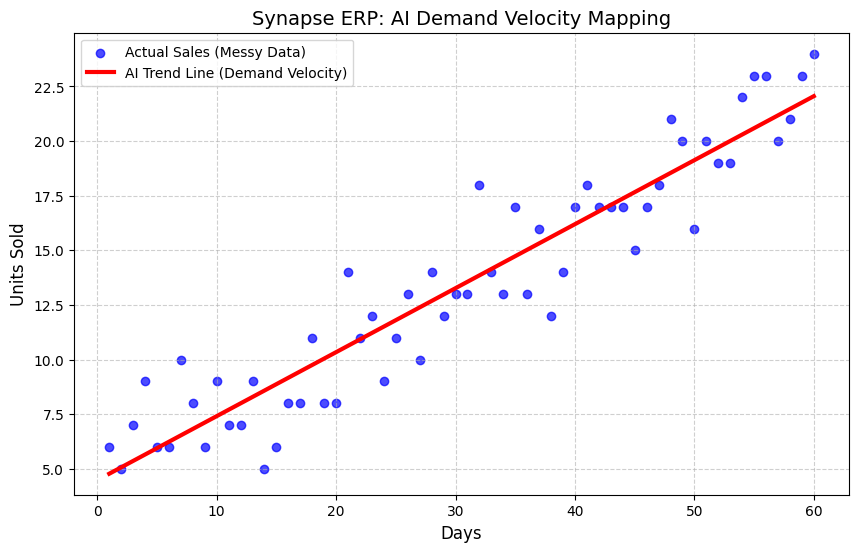

In [2]:
# Create a new cell and run this to visualize your AI's brain
plt.figure(figsize=(10, 6))

# 1. Plot the actual messy historical sales data as dots
plt.scatter(df_sales['Day'], df_sales['Units_Sold'], color='blue', label='Actual Sales (Messy Data)', alpha=0.7)

# 2. Plot the perfect line that your Scikit-Learn model calculated
trained_line = model.predict(days)
plt.plot(df_sales['Day'], trained_line, color='red', linewidth=3, label='AI Trend Line (Demand Velocity)')

# 3. Add labels and styling
plt.title('Synapse ERP: AI Demand Velocity Mapping', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the chart directly inside your notebook!
plt.show()

In [3]:
# Create a new cell to calculate how accurate your AI line is
from sklearn.metrics import r2_score, mean_squared_error

# 1. Calculate the predictions for our historical days
historical_predictions = model.predict(days)

# 2. Calculate Evaluation Metrics
r2 = r2_score(sales_quantity, historical_predictions)
mse = mean_squared_error(sales_quantity, historical_predictions)

print("--- AI Model Performance Metrics ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

--- AI Model Performance Metrics ---
R-squared (R2) Score: 0.8879
Mean Squared Error (MSE): 3.25


In [1]:
import sqlite3
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Connect directly to your local SQLite database
db_path = "erp_system.db"
conn = sqlite3.connect(db_path)

# 2. SQL Query to aggregate messy transactions into a clean timeline
# This groups all transactions by day and sums up the sales values
query = """
SELECT 
    CAST(strftime('%d', Transaction_Date) AS INTEGER) as Day_Number,
    SUM(Amount) as Total_Sales
FROM Transactions
GROUP BY Day_Number
ORDER BY Day_Number ASC;
"""

# 3. Read the SQL data straight into a Pandas DataFrame
df_real_sales = pd.read_sql_query(query, conn)
conn.close() # Always close the connection when done

print("--- Real Database Sales Timeline ---")
print(df_real_sales.head())

# 4. Format data for Scikit-Learn (Features must be 2D array)
X_real = df_real_sales['Day_Number'].values.reshape(-1, 1)
y_real = df_real_sales['Total_Sales'].values

# 5. Train the model on your live database data
real_model = LinearRegression()
real_model.fit(X_real, y_real)

print("\n--- Real Data ML Training Complete ---")
print(f"Real Market Demand Velocity: {real_model.coef_[0]:.2f} per day")

--- Real Database Sales Timeline ---
   Day_Number  Total_Sales
0           1      1964.03
1           2      2274.27
2           3      2356.92
3           4       -72.97
4           5      1879.17

--- Real Data ML Training Complete ---
Real Market Demand Velocity: 34.77 per day


In [2]:
# Create a new cell to calculate PURE sales velocity (filtering out expenses)
conn = sqlite3.connect("erp_system.db")

# We add a WHERE clause to only grab 'SALES' or positive transaction flows
refined_query = """
SELECT 
    CAST(strftime('%d', Transaction_Date) AS INTEGER) as Day_Number,
    SUM(Amount) as Total_Sales
FROM Transactions
WHERE Raw_String LIKE '%SALES%' OR Raw_String LIKE '%STRIPE%'  -- Pure revenue filters
GROUP BY Day_Number
ORDER BY Day_Number ASC;
"""

df_clean_sales = pd.read_sql_query(refined_query, conn)
conn.close()

# Retrain our Scikit-Learn model on clean metrics
X_clean = df_clean_sales['Day_Number'].values.reshape(-1, 1)
y_clean = df_clean_sales['Total_Sales'].values

clean_model = LinearRegression()
clean_model.fit(X_clean, y_clean)

print("--- Clean Revenue Sales Timeline ---")
print(df_clean_sales.head())
print(f"\nRefined Revenue Growth Velocity: {clean_model.coef_[0]:.2f} per day")

--- Clean Revenue Sales Timeline ---
   Day_Number  Total_Sales
0           1       665.49
1           2       142.32
2           4      -255.21
3           5        72.31
4           7       356.12

Refined Revenue Growth Velocity: 41.38 per day


In [3]:
# The Bulletproof Production Query
conn = sqlite3.connect("erp_system.db")

# Filter strictly for positive financial inflows (Amount > 0)
perfect_query = """
SELECT 
    CAST(strftime('%d', Transaction_Date) AS INTEGER) as Day_Number,
    SUM(Amount) as Total_Sales
FROM Transactions
WHERE Amount > 0  -- Force the database to only give us pure incoming revenue
GROUP BY Day_Number
ORDER BY Day_Number ASC;
"""

df_perfect_sales = pd.read_sql_query(perfect_query, conn)
conn.close()

# Retrain the final model
X_perf = df_perfect_sales['Day_Number'].values.reshape(-1, 1)
y_perf = df_perfect_sales['Total_Sales'].values

final_model = LinearRegression()
final_model.fit(X_perf, y_perf)

print("--- Bulletproof Revenue Timeline ---")
print(df_perfect_sales.head())
print(f"\nFinal Absolute Revenue Velocity: {final_model.coef_[0]:.2f} per day")

--- Bulletproof Revenue Timeline ---
   Day_Number  Total_Sales
0           1      2877.27
1           2      3128.09
2           3      2496.14
3           4       182.24
4           5      2698.02

Final Absolute Revenue Velocity: 32.41 per day
